# 04 Feature Extraction All Subjects

Runs the full progress-phase pipeline for all matched subjects, saves per-subject PSD files, creates the summary CSV, and records failures without stopping the run.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd

from dataset_loader import create_subject_metadata
from feature_extraction import build_summary_row, compute_welch_psd, save_psd_features
from preprocessing import preprocess_subject
from utils import METADATA_DIR, RAW_DATASET_DIR

In [2]:
metadata_df = create_subject_metadata(RAW_DATASET_DIR, verbose=False)
summary_rows = []
failures = []
run_rows = []

for row in metadata_df.itertuples(index=False):
    try:
        preprocessed = preprocess_subject(row.eeg_file)
        epoch_array = preprocessed['epoch_array']
        if epoch_array.size == 0:
            raise ValueError('No epochs retained after artifact rejection.')

        psd_features, freqs = compute_welch_psd(epoch_array, sfreq=preprocessed['raw'].info['sfreq'])
        output_path = save_psd_features(row.subject_id, row.class_name, int(row.label), psd_features, freqs)
        summary_rows.append(build_summary_row(row.subject_id, row.class_name, int(row.label), psd_features, output_path))
        run_rows.append({
            'subject_id': row.subject_id,
            'class_name': row.class_name,
            'label': int(row.label),
            'n_epochs': int(epoch_array.shape[0]),
            'rejected_epochs': preprocessed['reject_stats']['rejected_epochs'],
            'retained_epochs': preprocessed['reject_stats']['retained_epochs'],
        })
    except Exception as exc:
        failures.append({'subject_id': row.subject_id, 'class_name': row.class_name, 'error': str(exc)})

summary_df = pd.DataFrame(summary_rows)
summary_path = METADATA_DIR / 'psd_feature_summary.csv'
summary_df.to_csv(summary_path, index=False)

run_df = pd.DataFrame(run_rows)
failures_df = pd.DataFrame(failures)
summary_df.head()

,subject_id,class_name,label,n_epochs,n_channels,n_freq_bins,output_file
0,sub-001,AD,0,138,19,89,data\processed\psd_features\sub-001_psd_featur...
1,sub-002,AD,0,180,19,89,data\processed\psd_features\sub-002_psd_featur...
2,sub-003,AD,0,76,19,89,data\processed\psd_features\sub-003_psd_featur...
3,sub-004,AD,0,143,19,89,data\processed\psd_features\sub-004_psd_featur...
4,sub-005,AD,0,151,19,89,data\processed\psd_features\sub-005_psd_featur...


In [3]:
print('total subjects found:', len(metadata_df))
print('successfully processed:', len(summary_df))
print('failed subjects:', len(failures_df))
print(f"Total Subjects: {len(metadata_df)}")
print(f"Total Rejected Epochs: {int(run_df['rejected_epochs'].sum()) if not run_df.empty else 0}")
print(f"Average Epochs per Subject: {run_df['retained_epochs'].mean():.2f}" if not run_df.empty else 'Average Epochs per Subject: 0.00')
print('summary CSV:', summary_path)
if not failures_df.empty:
    display(failures_df)

total subjects found: 88
successfully processed: 88
failed subjects: 0
Total Subjects: 88
Total Rejected Epochs: 3244
Average Epochs per Subject: 163.18
summary CSV: D:\2026 MTECH Project\alz_project\data\metadata\psd_feature_summary.csv


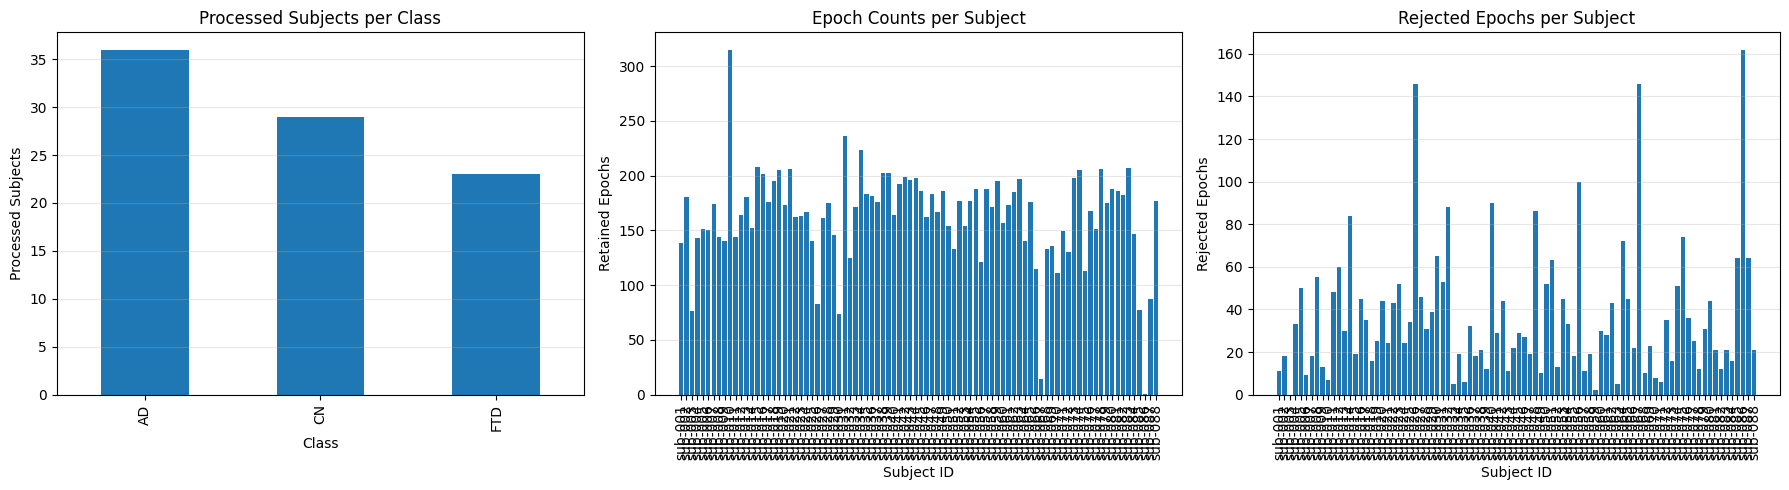

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if not run_df.empty:
    run_df.groupby('class_name')['subject_id'].count().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Processed Subjects per Class')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Processed Subjects')
    axes[0].grid(True, axis='y', alpha=0.3)

    axes[1].bar(run_df['subject_id'], run_df['n_epochs'])
    axes[1].set_title('Epoch Counts per Subject')
    axes[1].set_xlabel('Subject ID')
    axes[1].set_ylabel('Retained Epochs')
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].grid(True, axis='y', alpha=0.3)

    axes[2].bar(run_df['subject_id'], run_df['rejected_epochs'])
    axes[2].set_title('Rejected Epochs per Subject')
    axes[2].set_xlabel('Subject ID')
    axes[2].set_ylabel('Rejected Epochs')
    axes[2].tick_params(axis='x', rotation=90)
    axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()